In [34]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import torch
import math

In [43]:
# Load image
#image_path = "inaturalist_12K/train/Mammalia/0da9d10fd3085282087e1019af4fd262.jpg"  # Seal
image_path =  "inaturalist_12K/train/Mammalia/4c99765473a3747bb3eb847d57035134.jpg" # Animal on tree
#image_path = "inaturalist_12K/train/Amphibia/1a800a65d71c838e766758cf1fefdbf8.jpg"  # Frog in hand
image = cv2.imread(image_path)[:, :, ::-1]

In [38]:
# Load SAM model (use vit_b for laptop)
model_type = "vit_b"
checkpoint_path = "sam_vit_b_01ec64.pth"  # download from repo
sam = sam_model_registry[model_type](checkpoint=checkpoint_path)

In [39]:
# CPU/GPU selection
device = "cuda" if torch.cuda.is_available() else "cpu"
sam.to(device)

# Automatic mask generator
mask_generator = SamAutomaticMaskGenerator(sam,
                                           points_per_side=8,  # Change back to 32 for HPC usage
                                           pred_iou_thresh=0.9,
                                           stability_score_thresh=0.8)

In [44]:
masks = mask_generator.generate(image)

In [45]:
# What is the best mask?
h, w = image.shape[:2]
image_area = h * w
center = np.array([w // 2, h // 2])

best_score = math.inf
best_mask = None

scores = []

for m in masks:
    mask = m["segmentation"]
    area = m["area"]

    # Compute centroid
    ys, xs = np.where(mask)
    if len(xs) == 0:
        continue
    centroid = np.array([xs.mean(), ys.mean()])

    # Distance to center
    dist = np.linalg.norm(centroid - center, ord=2)     # Euclidean norm

    # Normalize area
    area_ratio = area / image_area

    # Scoring
    score = dist * 0.001 - area_ratio * 1.0
    # Old scoring
    #score = area - 0.5 * dist
    scores.append(score)

    if score < best_score:
        best_score = score
        best_mask = mask

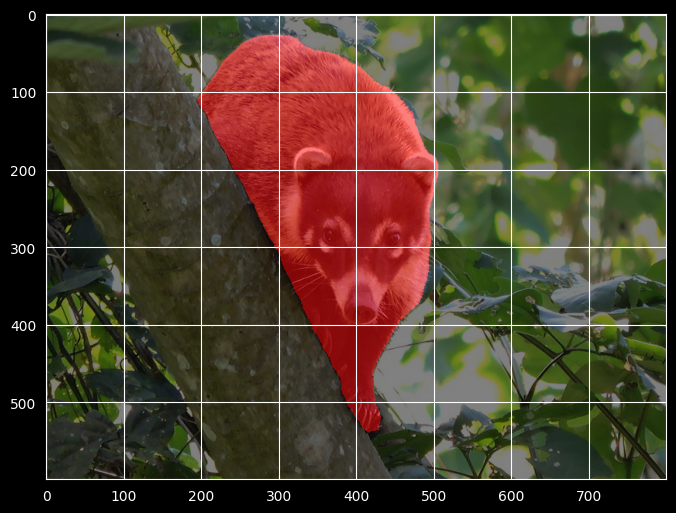

In [47]:
plt.figure(figsize=(8, 8))
plt.imshow(image)

colored_mask = np.zeros((*best_mask.shape, 3))
colored_mask[best_mask] = [1, 0, 0]

plt.imshow(colored_mask, alpha=0.5)
plt.show()